# Fine-Tuning

# Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
)
from datasets import Dataset
from peft import LoraConfig, TaskType
import xgboost as xgb
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

2026-03-02 08:30:57.643370: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 08:30:58.157342: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/dkusmenko/.local/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving

In [2]:
import os
# This enables memory fragmentation handling specifically for AMD HIP
os.environ["PYTORCH_HIP_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
import torch
def print_gpu_utilization():
    if not torch.cuda.is_available():
        print("No GPU detected.")
        return

    # On AMD ROCm, 'cuda' functions query the HIP backend
    reserved = torch.cuda.memory_reserved()
    allocated = torch.cuda.memory_allocated()
    total_memory = torch.cuda.get_device_properties(0).total_memory
    
    print(f"Total GPU Mem: {total_memory / 1024**3:.2f} GB")
    print(f"Reserved (Cached): {reserved / 1024**3:.2f} GB")
    print(f"Allocated (Active): {allocated / 1024**3:.2f} GB")
    print(f"Free (Approx): {(total_memory - reserved) / 1024**3:.2f} GB")
    print("-" * 30)

# Run it
print_gpu_utilization()

Total GPU Mem: 15.82 GB
Reserved (Cached): 0.00 GB
Allocated (Active): 0.00 GB
Free (Approx): 15.82 GB
------------------------------


/home/dkusmenko/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:736: UserWarning: Can't initialize amdsmi - Error code: 34
  warnings.warn(f"Can't initialize amdsmi - Error code: {e.err_code}")


# Data Import, Clean, and Sample

In [ ]:
# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
# Load in freMTPL2freq dataset
dataset = fetch_openml(data_id=41214, as_frame=True)
full_df = dataset.frame

# Clean basic types first
full_df['ClaimNb'] = pd.to_numeric(full_df['ClaimNb'])
full_df['Exposure'] = pd.to_numeric(full_df['Exposure'])
full_df['Exposure'] = full_df['Exposure'].clip(upper=1.0)
full_df['Frequency'] = full_df['ClaimNb'] / full_df['Exposure']

# mapping for contextualized factors
brand_mapping = {'B1': 'Renault, Nissan, or Citroen', 'B2': 'Renault, Nissan, or Citroen',
                 'B3': 'Volkswagen, Audi, Skoda, or Seat', 'B4': 'Opel, General Motors, or Ford',
                 'B5': 'Opel, General Motors, or Ford','B6': 'Fiat', 'B10':'Mercedes, Chrysler, or BMW',
                 'B11':'Mercedes, Chrysler, or BMW', 'B12': 'Japanese (except Nissan) or Korean', 'B13': 'Other','B14': 'Other' }

region_mapping = {
    "R11": "Île-de-France",
    "R21": "Champagne-Ardenne",
    "R22": "Picardie",
    "R23": "Haute-Normandie",
    "R24": "Centre",
    "R25": "Basse-Normandie",
    "R26": "Bourgogne",
    "R31": "Nord–Pas-de-Calais",
    "R41": "Lorraine",
    "R42": "Alsace",
    "R43": "Franche–Comté",
    "R52": "Pays de la Loire",
    "R53": "Bretagne",
    "R54": "Poitou–Charentes",
    "R72": "Aquitaine",
    "R73": "Midi–Pyrénées",
    "R74": "Limousin",
    "R82": "Rhône–Alpes",
    "R83": "Auvergne",
    "R91": "Languedoc–Roussillon",
    "R93": "Provence–Alpes–Côte d’Azur",
    "R94": "Corse"
}

area_mapping = {
    "A": "rural area",
    "B": "semi-rural area",
    "C": "suburban-fringe area",
    "D": "suburban area",
    "E": "urban area",
    "F": "urban center"
}

gas_mapping = {
    "'Diesel'": "Diesel",
    "'Regular'": "Regular"

}

full_df["VehBrand"] = full_df["VehBrand"].map(brand_mapping)
full_df["Region"] = full_df["Region"].map(region_mapping)
full_df["Area"] = full_df["Area"].map(area_mapping)
full_df["VehGas"] = full_df["VehGas"].map(gas_mapping)


Loading freMTPL2freq dataset...
Stratified Subset Size: 100000
Claim Rate in Subset: 0.0502
Claim Rate in Full Data: 0.0502 (Should match)
Final Train: 80000 | Final Test: 20000


In [ ]:
# Load the split indices
df_splits = pd.read_csv('../freMTPL2freq_split_indices.csv')

# Ensure IDpol is the same type in both dataframes for a clean merge
full_df['IDpol'] = full_df['IDpol'].astype(int)
df_splits['IDpol'] = df_splits['IDpol'].astype(int)

# Merge the dataset with the split indicators
# We use a left join to keep the original data rows
df_merged = full_df.merge(df_splits, on='IDpol', how='left')

# Create the subsets based on the indicator columns
train_df = df_merged[df_merged['is_train'] == 1].drop(columns=['is_train', 'is_test', 'is_finetune']).copy()
test_df = df_merged[df_merged['is_test'] == 1].drop(columns=['is_train', 'is_test', 'is_finetune']).copy()
finetune_df = df_merged[df_merged['is_finetune'] == 1].drop(columns=['is_train', 'is_test', 'is_finetune']).copy()

# Print results
print(f"Total rows: {len(full_df)}")
print(f"Train rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")
print(f"Finetune rows: {len(finetune_df)}")

# Inspect the training set
print(train_df.head())

# Create Prompts

In [ ]:
# ==========================================
# 2. SERIALIZATION (Tabular -> Text)
# ==========================================
def serialize_row(row):
    """
    Converts a row of insurance covariates into a natural language prompt.
    Uses a fixed template for consistency between Training and Inference.
    """
    # Handling categorical values cleanly
    veh_brand = str(row['VehBrand']).strip()
    veh_gas = str(row['VehGas']).strip()
    area = str(row['Area']).strip()
    region = str(row['Region']).strip()
    
    return (
        f"DrivAge={row['DrivAge']}, Area={area}, Region={region}, Density={row['Density']}, "
        f"VehBrand={veh_brand}, VehAge={row['VehAge']}, VehGas={veh_gas}, VehPower={row['VehPower']}, "
        f"BonusMalus={row['BonusMalus']}"
    )

# Apply serialization
print("Serializing rows to text...")
train_df['text_desc'] = train_df.apply(serialize_row, axis=1)
test_df['text_desc'] = test_df.apply(serialize_row, axis=1)

Serializing rows to text...


### Example Prompt

DrivAge=18, Area=Urban area, Region=Centre, Density=1020,
VehBrand=Renault/Nissan/Citroën, VehAge=1, VehGas=Diesel, VehPower=7,
BonusMalus=100

# Downsteam GLM

# Using Fine-Tuned Model (after training)

In [ ]:
# Initialize Model
model = SentenceTransformer(
    "Qwen/Qwen3-Embedding-0.6B", 
    trust_remote_code=True, 
    device="cuda",
    model_kwargs={
        "torch_dtype": torch.float16,   # Critical for speed/VRAM
        "attn_implementation": "sdpa"   # Faster attention
    }
)

`torch_dtype` is deprecated! Use `dtype` instead!
/home/dkusmenko/.local/lib/python3.10/site-packages/torch/nn/modules/module.py:1329: UserWarning: expandable_segments not supported on this platform (Triggered internally at /pytorch/c10/hip/HIPAllocatorConfig.h:29.)
  return t.to(


In [ ]:
# Test Model works
print("Model loaded successfully!")
with model.truncate_sentence_embeddings(truncate_dim=64):
    embeddings_truncated = model.encode(["hello there", "hiya"])
assert embeddings_truncated.shape[-1] == 64

Model loaded successfully!


In [16]:
embeddings_truncated

array([[-0.01862  , -0.007812 , -0.01043  , -0.0416   ,  0.00637  ,
        -0.00972  , -0.03528  ,  0.03114  , -0.0937   ,  0.01201  ,
         0.002016 , -0.03111  ,  0.1039   , -0.00924  , -0.05087  ,
         0.0857   , -0.02142  ,  0.0631   ,  0.10956  , -0.0799   ,
         0.03464  ,  0.0085   , -0.04028  ,  0.1392   ,  0.006653 ,
        -0.00534  , -0.0316   ,  0.10675  ,  0.0215   , -0.01288  ,
         0.02158  ,  0.03146  , -0.00978  , -0.002033 , -0.03592  ,
        -0.01346  , -0.01267  ,  0.0004709, -0.03094  ,  0.0586   ,
        -0.01813  ,  0.02397  ,  0.0669   , -0.01537  , -0.003511 ,
        -0.0279   ,  0.05136  , -0.00895  , -0.000533 , -0.006157 ,
        -0.028    , -0.02452  ,  0.011826 ,  0.008286 ,  0.008125 ,
        -0.05804  ,  0.05334  , -0.004417 ,  0.04184  , -0.00953  ,
        -0.0937   ,  0.051    , -0.02545  ,  0.00911  ],
       [-0.001335 ,  0.0176   , -0.01573  , -0.0507   ,  0.03174  ,
        -0.02054  ,  0.004562 ,  0.0933   , -0.0811   ,  0.

Model is outputting embeddings of dim 64

### Check VRAM Usage

In [ ]:
print_gpu_utilization()

Total GPU Mem: 15.82 GB
Reserved (Cached): 1.13 GB
Allocated (Active): 1.11 GB
Free (Approx): 14.69 GB
------------------------------


Now want to generate embeddings from data

Ensure model is running on GPU

In [9]:
print(model.device)

cuda:0


In [10]:
import torch

# 1. Define the device (On AMD ROCm, we still call it 'cuda' in PyTorch)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Moving model to: {device}")

# 2. Move the model
model = model.to(device)

Moving model to: cuda


In [ ]:
print("Generating embeddings for GLM...")

train_embeddings= model.encode(train_df['text_desc'].tolist(), batch_size=64, show_progress_bar=True)
test_embeddings = model.encode(test_df['text_desc'].tolist(), batch_size=64, show_progress_bar=True)

Generating embeddings for GLM...


Batches:   0%|          | 0/2500 [00:00<?, ?it/s]

/home/dkusmenko/.local/lib/python3.10/site-packages/transformers/integrations/sdpa_attention.py:96: UserWarning: Mem Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:302.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
/home/dkusmenko/.local/lib/python3.10/site-packages/transformers/integrations/sdpa_attention.py:96: UserWarning: Flash Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:256.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


Batches:   0%|          | 0/625 [00:00<?, ?it/s]

In [ ]:
import numpy as np

# Save everything in one single archive
np.savez(
    "../embeddings/train_embeddings_minimalkeyvalue.npz", 
    X=train_embeddings,           # The Features (Embeddings)
    y=train_df['ClaimNb'].values, # The Target (Counts)
    w=train_df['Exposure'].values # The Weight (Exposure)
)
print("Saved all training data to ../embeddings/train_embeddings_minimalkeyvalue.npz")
np.savez(
    "../embeddings/test_embeddings_minimalkeyvalue.npz", 
    X=test_embeddings,           # The Features (Embeddings)
    y=test_df['ClaimNb'].values, # The Target (Counts)
    w=test_df['Exposure'].values # The Weight (Exposure)
)

print("Saved all testing data to ../embeddings/test_embeddings_minimalkeyvalue.npz")



Saved all training data to insurance_training_data_100_base.npz
Saved all testing data to insurance_testing_data_100_base.npz


In [ ]:
import numpy as np
train_df = np.load("../embeddings/train_embeddings_minimalkeyvalue.npz")

test_df = np.load("../embeddings/test_embeddings_minimalkeyvalue.npz")

Want to have embeddings -- claim count -- exposure

In [14]:
meta_train = [train_df['y'], train_df['w']]

In [ ]:
# Partition Data
X_train = train_df['X']
meta_train = [train_df['y'], train_df['w']]

meta_train = pd.DataFrame({
    'ClaimNb': meta_train[0],
    'Exposure': meta_train[1]
})


X_test = test_df['X']
meta_test = [test_df['y'], test_df['w']]

meta_test = pd.DataFrame({
    'ClaimNb': meta_test[0],
    'Exposure': meta_test[1]
})

# Setup Scaler & PCA with Pandas Output
scaler = StandardScaler().set_output(transform='pandas')
pca = PCA(n_components=100).set_output(transform='pandas')

# Pipeline Execution
# TRAIN: Fit & Transform
# Scaler returns a DF with index preserved -> PCA returns a DF with index preserved
X_train_scaled = scaler.fit_transform(X_train)
X_train_pca = pca.fit_transform(X_train_scaled)

# TEST: Transform Only
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

# Reconstruction
# Because indices are preserved, pandas aligns rows automatically.
# We can also rename columns cleanly if we want "PC1" instead of "pca0"

# Rename columns from 'pca0' to 'PC1', 'PC2'...
new_col_names = [f"PC{i+1}" for i in range(100)]
X_train_pca.columns = new_col_names
X_test_pca.columns = new_col_names

# Concatenate (Join)
final_train = pd.concat([X_train_pca, meta_train], axis=1)
final_test = pd.concat([X_test_pca, meta_test], axis=1)

print(f"Original Predictors: {len(X_train)}")
print(f"Reduced Predictors:  {X_train_pca.shape[1]}")
print(f"Final Train Shape:   {final_train.shape}")
print(final_train.head())

Original Predictors: 80000
Reduced Predictors:  48
Final Train Shape:   (80000, 50)
         PC1        PC2        PC3        PC4        PC5       PC6       PC7  \
0   7.075263   5.375508  19.094503  -4.984406  -3.900136 -1.575254 -7.887062   
1  -4.665423 -12.092338   6.035984   2.627325   6.284460  1.693932  0.802429   
2  -3.857218  -8.809327   1.059200   4.463825  -1.637203 -3.476277  6.471164   
3   1.962208  17.962362   6.949534  -6.392969  20.634046 -1.049934  2.457373   
4 -11.673639  -7.259607  -1.913346 -14.846736  -3.626096 -5.123259  5.885425   

         PC8       PC9      PC10  ...      PC41      PC42      PC43      PC44  \
0 -12.415404 -2.264127 -1.380780  ... -1.272945  0.052969 -2.253575  1.399411   
1  -5.921920  1.739554  2.091042  ... -1.772792 -5.010557 -4.871077  1.424104   
2   3.192330  6.208368 -1.992678  ...  1.093231 -1.981427 -0.486208  0.254681   
3   9.856289 -3.627549 -2.043559  ...  0.133052  0.918947 -0.645943  1.412581   
4   5.308855 -3.081442  1.6099

In [ ]:
# Extract Variance Proportions
ex_var_ratio = pca.explained_variance_ratio_
cum_var_ratio = np.cumsum(ex_var_ratio)

# Create a Summary DataFrame
df_variance = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(ex_var_ratio))],
    'Individual_Variance': ex_var_ratio*100,
    'Cumulative_Variance': cum_var_ratio*100
})

df_variance

,Component,Individual_Variance,Cumulative_Variance
0,PC1,10.448951,10.448951
1,PC2,7.885148,18.334099
2,PC3,6.912794,25.246893
3,PC4,5.502181,30.749074
4,PC5,4.973171,35.722245
5,PC6,4.154026,39.876271
6,PC7,4.063855,43.940126
7,PC8,3.778428,47.718554
8,PC9,3.536732,51.255286
9,PC10,3.202682,54.457968


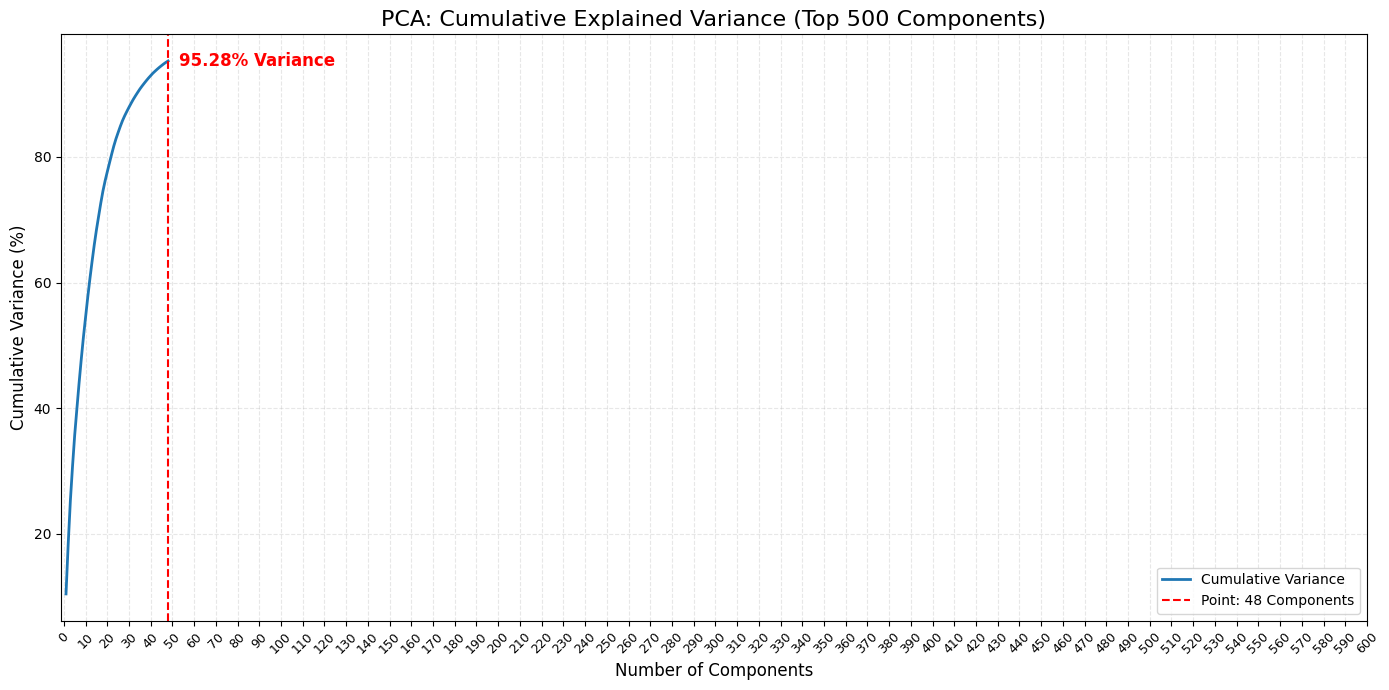

In [ ]:
# Filter the data to the first 500 components
df_subset = df_variance

# Extract the variance explained by exactly 48 components
# Since Python is 0-indexed, PC48 is at index 47
var_at_48 = df_subset.iloc[47]['Cumulative_Variance']

# Set up the figure
plt.figure(figsize=(14, 7))

# Plot the cumulative variance curve
plt.plot(range(1, len(df_subset) + 1), df_subset['Cumulative_Variance'], 
         color='tab:blue', linewidth=2, label='Cumulative Variance')

# Add a vertical line at 48 components
plt.axvline(x=48, color='red', linestyle='--', linewidth=1.5, label='Point: 48 Components')

# Add a text label showing the variance explained at n=48
# We offset the x position slightly (+5) so the text doesn't sit on the line
plt.text(48 + 5, var_at_48, f'{var_at_48:.2f}% Variance', 
         color='red', fontweight='bold', fontsize=12, verticalalignment='center')

# Set x-axis ticks to show every 10th component for clarity
plt.xticks(range(0, 101, 10), rotation=45, fontsize=9)

# Formatting labels and title
plt.title('PCA: Cumulative Explained Variance (Top 100 Components)', fontsize=16)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Variance (%)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(loc='lower right')

# Adjust layout and show
plt.tight_layout()
#plt.savefig('var_curve.png')
plt.show()

In [ ]:
# Generate 1,024 column names (embedding_1, embedding_2, ..., embedding_1024)
# We use i+1 so the count starts at 1 instead of 0
col_names = [f"embedding_{i+1}" for i in range(X_train.shape[1])]

# Create the DataFrame
X_train = pd.DataFrame(X_train, columns=col_names, copy=False)

print(X_train.head())

   embedding_1  embedding_2  embedding_3  embedding_4  embedding_5  \
0    -0.049835    -0.013626    -0.011513     0.037598     0.073425   
1    -0.024246     0.008965    -0.012085     0.049347     0.076538   
2    -0.032288    -0.009499    -0.012909     0.055511     0.071594   
3    -0.006241    -0.019241    -0.012276     0.052734     0.060394   
4    -0.023346    -0.015701    -0.011505     0.053528     0.063538   

   embedding_6  embedding_7  embedding_8  embedding_9  embedding_10  ...  \
0    -0.040070     0.036194     0.025620    -0.044861      0.017105  ...   
1    -0.037140     0.030884     0.020493    -0.047485     -0.001226  ...   
2    -0.051819     0.019501     0.024048    -0.047516      0.011230  ...   
3    -0.041046     0.037476     0.008186    -0.076477     -0.008301  ...   
4    -0.043640     0.029358     0.003124    -0.056366      0.018417  ...   

   embedding_1015  embedding_1016  embedding_1017  embedding_1018  \
0        0.034943        0.030914        0.018402    

/home/dkusmenko/.local/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [ ]:
# Generate 1,024 column names (embedding_1, embedding_2, ..., embedding_1024)
# We use i+1 so the count starts at 1 instead of 0
col_names = [f"embedding_{i+1}" for i in range(X_test.shape[1])]

# Create the DataFrame
X_test = pd.DataFrame(X_test, columns=col_names, copy=False)


Processing Training Size: 200
Processing Training Size: 500
Processing Training Size: 1000
Processing Training Size: 2500
Processing Training Size: 5000
Processing Training Size: 10000
Processing Training Size: 15000
Processing Training Size: 20000
Processing Training Size: 30000
Processing Training Size: 50000
Processing Training Size: 80000


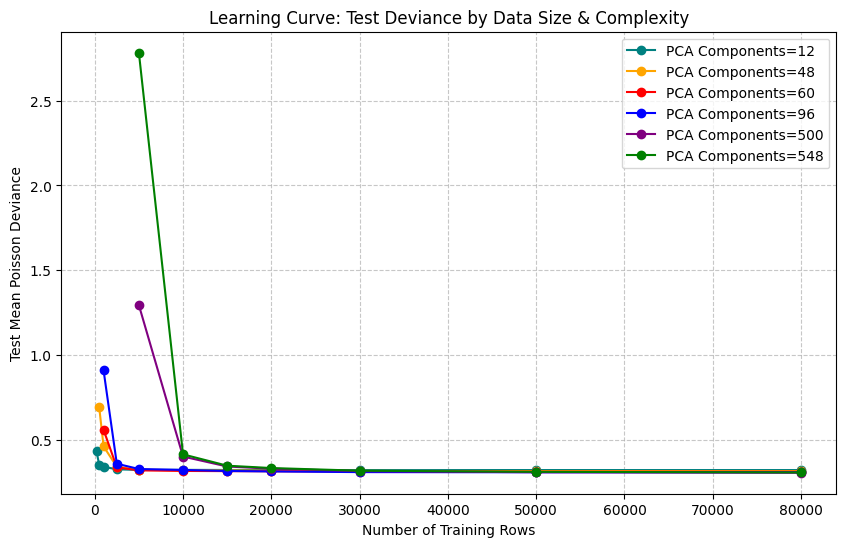

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_poisson_deviance
import statsmodels.api as sm
import gc

# -------------------------------------------------------
# Setup, Extraction & Random Shuffle
# -------------------------------------------------------
# Extracting arrays from the NpzFile 
X_raw_all = train_df['X']
y_raw_all = train_df['y']
w_raw_all = train_df['w']

# Create a random permutation of indices to shuffle X, y, and w together
np.random.seed(42)
indices = np.random.permutation(len(y_raw_all))

# Apply shuffled indices
X_train_shuffled = X_raw_all[indices]
y_train_shuffled = y_raw_all[indices]
offset_train_shuffled = w_raw_all[indices]

# Setup Test Data (Assuming test_df is also an NpzFile or similar)
X_test_raw = np.array(test_df['X'])
y_test = np.array(test_df['y'])
offset_test = np.array(test_df['w'])

# -------------------------------------------------------
# Configuration
# -------------------------------------------------------
# Use the same size logic, ensuring we don't exceed actual data size
max_available = len(y_train_shuffled)
train_sizes = [s for s in [200, 500, 1000, 2500, 5000, 10000, 15000, 20000, 30000, 50000, 80000] if s <= max_available]

start_thresholds = {
    12: 200, 48: 500, 60: 1000, 96: 1000, 500: 5000, 548: 5000
}

component_sets = [12, 48, 60, 96, 500, 548]
results_history = {k: [] for k in component_sets}

# -------------------------------------------------------
# Learning Curve Loop (Randomly Sampled)
# -------------------------------------------------------
for size in train_sizes:
    print(f"Processing Training Size: {size}")
    
    # --- Slice Data (already shuffled, so iloc-equivalent slicing is random) ---
    X_train_sub = X_train_shuffled[:size]
    y_train_sub = y_train_shuffled[:size]
    off_train_sub = offset_train_shuffled[:size]
    
    # --- Scaling ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sub)
    X_test_scaled = scaler.transform(X_test_raw)

    # --- PCA (Dynamic Fitting per Subset) ---
    n_features = X_train_scaled.shape[1]
    max_k_possible = min(size, n_features, 548)
    
    pca = PCA(n_components=max_k_possible, random_state=42)
    X_train_pca_all = pca.fit_transform(X_train_scaled)
    X_test_pca_all = pca.transform(X_test_scaled)

    # Cleanup intermediate large objects
    del X_train_scaled, X_test_scaled, scaler, pca
    gc.collect()

    # --- Loop through component configurations ---
    for k in component_sets:
        # Check Rules
        if size < start_thresholds[k] or k > max_k_possible:
            results_history[k].append(np.nan)
            continue
            
        # Slice components
        X_train_k = X_train_pca_all[:, :k]
        X_test_k = X_test_pca_all[:, :k]
        
        try:
            glm = sm.GLM(
                endog=y_train_sub, 
                exog=sm.add_constant(X_train_k), 
                offset=np.log(off_train_sub), 
                family=sm.families.Poisson()
            )
            res = glm.fit(disp=0)
            
            # Predict and Score
            X_test_glm = sm.add_constant(X_test_k, has_constant='add')
            preds = res.predict(exog=X_test_glm, offset=np.log(offset_test))
            
            mpd = mean_poisson_deviance(y_test, preds)
            results_history[k].append(mpd)
            
        except Exception as e:
            print(f"  Failed for k={k} at size={size}: {e}")
            results_history[k].append(np.nan)

    del X_train_pca_all, X_test_pca_all
    gc.collect()

# -------------------------------------------------------
# Plotting
# -------------------------------------------------------
plt.figure(figsize=(10, 6))
colors = {12: 'teal', 48: 'orange', 60: 'red', 96: 'blue', 500: 'purple', 548: 'green'}

for k in component_sets:
    # Filter NaNs for plotting
    valid_mask = [not np.isnan(r) for r in results_history[k]]
    sizes_valid = [s for s, m in zip(train_sizes, valid_mask) if m]
    scores_valid = [r for r, m in zip(results_history[k], valid_mask) if m]
    
    plt.plot(sizes_valid, scores_valid, marker='o', linestyle='-', 
             color=colors.get(k, 'black'), label=f'PCA K={k}')

plt.title('Randomized Learning Curve: Deviance by Data Size & Complexity')
plt.xlabel('Number of Training Rows (Randomly Sampled)')
plt.ylabel('Test Mean Poisson Deviance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Learning Curves

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.metrics import mean_poisson_deviance
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Handle NpzFile and Shuffle
# -------------------------------------------------------
# Extracting arrays from the NpzFile object
X_raw_all = train_df['X']
y_raw_all = train_df['y']
w_raw_all = train_df['w']

# Create a random permutation of indices to shuffle X, y, and w together
np.random.seed(42)
indices = np.random.permutation(len(y_raw_all))

X_train_full = X_raw_all[indices]
y_train_full = y_raw_all[indices]
offset_train_full = w_raw_all[indices]

# Setup Test Data (Assuming test_df is also an NpzFile or similar)
# We convert to numpy arrays immediately for consistency
X_test_raw = np.array(test_df['X'])
y_test = np.array(test_df['y'])
offset_test = np.array(test_df['w'])

# -------------------------------------------------------
# Learning Curve Loop
# -------------------------------------------------------
max_rows = len(y_train_full)
# Ensure we don't exceed actual data size
train_sizesr = np.geomspace(500, min(500000, max_rows), num=10, dtype=int)
deviancesr_2 = []
n_components = 48 

for size in train_sizesr:
    # Slice from the SHUFFLED numpy arrays
    X_train_sub_raw = X_train_full[:size]
    y_train_sub = y_train_full[:size]
    off_train_sub = offset_train_full[:size]
    
    try:
        # Fit PCA on the current training subset only
        pca = PCA(n_components=n_components)
        X_train_pca = pca.fit_transform(X_train_sub_raw)
        
        # Transform the FIXED Test set using the PCA fitted on this subset
        X_test_pca = pca.transform(X_test_raw)
        
        # Add constants for Statsmodels
        X_train_glm = sm.add_constant(X_train_pca)
        X_test_glm = sm.add_constant(X_test_pca, has_constant='add')
        
        # Fit GLM
        glm = sm.GLM(
            endog=y_train_sub, 
            exog=X_train_glm, 
            offset=np.log(off_train_sub), 
            family=sm.families.Poisson()
        )
        results = glm.fit()
        
        # Predict on transformed Test Set
        preds = results.predict(exog=X_test_glm, offset=np.log(offset_test))
        
        # Score
        mpd = mean_poisson_deviance(y_test, preds)
        deviancesr_2.append(mpd)
        print(f"Size {size}: {mpd:.5f}")
        
    except Exception as e:
        print(f"Size {size} failed: {e}")
        deviancesr_2.append(None)

# -------------------------------------------------------
# Plotting 
# -------------------------------------------------------
plt.figure(figsize=(10, 6))

# Filter out potential None values for the plot
valid_indices = [i for i, v in enumerate(deviancesr_2) if v is not None]
plt.plot(
    np.array(train_sizesr)[valid_indices], 
    np.array(deviancesr_2)[valid_indices], 
    marker='o', color='black', label=f'Randomized PCA ({n_components} comps)'
)

plt.xscale('log')
plt.title('Learning Curve: PCA + Poisson GLM (Random Sampling)')
plt.xlabel('Number of Training Rows')
plt.ylabel('Test Mean Poisson Deviance')
plt.grid(True, linestyle='--', alpha=0.7, which='both')
plt.legend()
plt.show()

Original Predictors: 80000
Reduced Predictors:  48
Final Train Shape:   (80000, 50)
         PC1        PC2        PC3        PC4        PC5       PC6       PC7  \
0   7.075263   5.375508  19.094503  -4.984406  -3.900136 -1.575254 -7.887062   
1  -4.665423 -12.092338   6.035984   2.627325   6.284460  1.693932  0.802429   
2  -3.857218  -8.809327   1.059200   4.463825  -1.637203 -3.476277  6.471164   
3   1.962208  17.962362   6.949534  -6.392969  20.634046 -1.049934  2.457373   
4 -11.673639  -7.259607  -1.913346 -14.846736  -3.626096 -5.123259  5.885425   

         PC8       PC9      PC10  ...      PC41      PC42      PC43      PC44  \
0 -12.415404 -2.264127 -1.380780  ... -1.273200  0.052989 -2.252564  1.391142   
1  -5.921920  1.739554  2.091042  ... -1.771680 -5.011598 -4.873127  1.420659   
2   3.192330  6.208368 -1.992678  ...  1.093448 -1.980777 -0.485458  0.256729   
3   9.856289 -3.627549 -2.043559  ...  0.133311  0.918813 -0.645476  1.408147   
4   5.308855 -3.081442  1.6099